## Replicate Figure 1
This notebook reproduces Figure 1 from the paper:
Bayesian Strategy Analysis.

It evaluates multiple strategies across trials and
plots their posterior probabilities.

In [ ]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import strategymodels

from Functions.set_Beta_prior import set_priors
from Functions.update_strategy_posterior_probability import update_strategy_posterior_probability
from Functions.Summaries_of_Beta_distribution import summaries_of_Beta_Distribution
from Functions.plotSessionStructure import plotSessionStructure
from Functions.interpolate_null_trials import interpolate_null_trials

In [36]:
# Load test data
TestData = pd.read_csv("data.csv")

# Strategies shown in Figure 1
strategies = [
    "go_left",
    "go_right",
    "go_cued",
    "win_stay_spatial",
    "lose_shift_cued",
    "lose_shift_spatial"
]

# Prior and decay settings
prior_type = "Uniform" # Options: "Uniform": alpha0 = 1, beta0 = 1; "Jeffreys": alpha0 = 0.5, beta0 = 0.5
decay_rate = 0.9 # Decay rate for the influence of past trials on the posterior probability

alpha0, beta0 = set_priors(prior_type) 

TestData.head()

,TrialIndex,SessionIndex,TargetRule,Choice,CuePosition,Reward,RuleChangeTrials,NewSessionTrials
0,1,15,go right,left,right,no,0,0
1,2,15,go right,left,right,no,0,0
2,3,15,go right,right,right,yes,0,0
3,4,15,go right,left,right,no,0,0
4,5,15,go right,left,right,no,0,0


In [37]:
# Initialise storage

Output_collection = {}
event_totals = {}

for strategy in strategies:
    
    Output_collection[strategy] = pd.DataFrame(
        columns=[
            "Alpha", "Beta",
            "MAPprobability", "Precision",
            "Alpha_interpolated", "Beta_interpolated",
            "MAPprobability_interpolated", "Precision_interpolated"
        ]
    )
    
    event_totals[strategy] = {
        "success_total": 0,
        "failure_total": 0
    }

In [38]:
# Run Bayesian strategy analysis across trials

for trial in range(len(TestData)):
    
    rows_of_data = TestData.iloc[0:trial+1]
    
    for strategy in strategies:
        
        strategy_fcn = getattr(strategymodels, strategy)
        trial_type = strategy_fcn(rows_of_data)
        
        success_total, failure_total, Alpha, Beta = update_strategy_posterior_probability(
            trial_type,
            decay_rate,
            event_totals[strategy]["success_total"],
            event_totals[strategy]["failure_total"],
            alpha0,
            beta0
        )
        
        event_totals[strategy]["success_total"] = success_total
        event_totals[strategy]["failure_total"] = failure_total
        
        MAPprobability = summaries_of_Beta_Distribution(Alpha, Beta, "MAP")
        precision = summaries_of_Beta_Distribution(Alpha, Beta, "precision")
        
        this_trials_data = {
            "Alpha": Alpha,
            "Beta": Beta,
            "MAPprobability": MAPprobability,
            "Precision": precision
        }
        
        if trial > 0:
            previous_trials_data = Output_collection[strategy].iloc[trial-1]
        else:
            previous_trials_data = Output_collection[strategy]
        
        new_row_of_data = interpolate_null_trials(
            this_trials_data,
            previous_trials_data,
            alpha0,
            beta0
        )
        
        Output_collection[strategy] = pd.concat(
            [Output_collection[strategy], pd.DataFrame([new_row_of_data])],
            ignore_index=True
        )

/var/folders/1p/18jwl7x13xdgtw3zwr3q9zfr0000gn/T/ipykernel_1303/3955232189.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Output_collection[strategy] = pd.concat(


In [42]:
strategy_name = "go_left"  # dominant strategy (blue line)
MAP = Output_collection[strategy_name]["MAPprobability"].values
len(MAP), MAP[:5]

(394, array([0.999, 0.999, 0.631, 0.738, 0.802]))

In [43]:
def detect_learning_sequence(map_prob, chance_level=0.5):
    map_prob = np.asarray(map_prob)

    for start in range(len(map_prob)):
        if np.all(map_prob[start:] > chance_level):
            mask = np.zeros(len(map_prob), dtype=bool)
            mask[start:] = True
            return start, mask

    return None, np.zeros(len(map_prob), dtype=bool)


In [44]:
chance_level = 0.5
learning_trial, learning_mask = detect_learning_sequence(MAP, chance_level=chance_level)


/var/folders/1p/18jwl7x13xdgtw3zwr3q9zfr0000gn/T/ipykernel_1303/1495471468.py:23: UserWarning: Legend does not support handles for Text instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


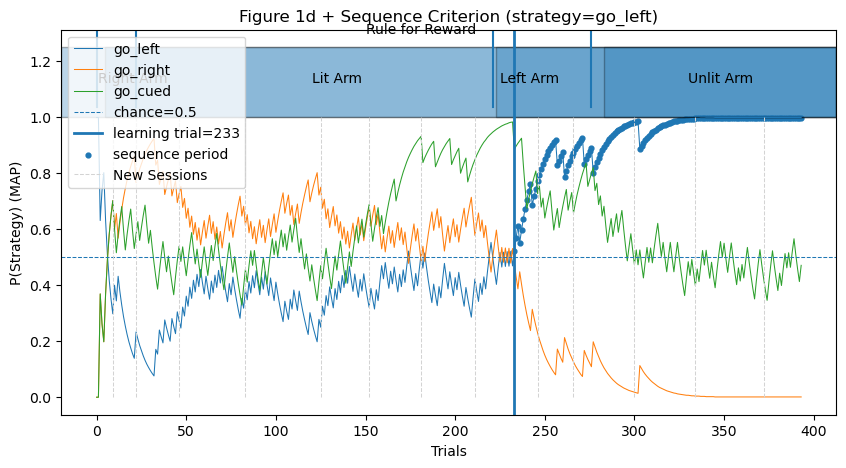

In [45]:
no_Trials = len(MAP)

plt.figure(figsize=(10, 5))

# Figure 1d lines
plt.plot(Output_collection["go_left"].MAPprobability, linewidth=0.75, label="go_left")
plt.plot(Output_collection["go_right"].MAPprobability, linewidth=0.75, label="go_right")
plt.plot(Output_collection["go_cued"].MAPprobability, linewidth=0.75, label="go_cued")


# Sequence criterion overlay
plt.axhline(y=chance_level, linestyle="--", linewidth=0.75, label=f"chance={chance_level}")

if learning_trial is not None:
    plt.axvline(x=learning_trial, linewidth=2, label=f"learning trial={learning_trial}")
    plt.scatter(np.where(learning_mask)[0], MAP[learning_mask], s=12, label="sequence period")

plt.xlabel("Trials")
plt.ylabel("P(Strategy) (MAP)")
plt.title(f"Figure 1d + Sequence Criterion (strategy={strategy_name})")

plotSessionStructure(TestData)
plt.legend()
plt.show()

In [46]:
strategy_name = "go_left"  # dominant (mavi çizgi)
MAP = Output_collection[strategy_name]["MAPprobability"].values
PREC = Output_collection[strategy_name]["Precision"].values

In [47]:
import numpy as np

def learning_trial_strategy2_paper_tie_ok(Output_collection, target="go_left", others=("go_right","go_cued"), chance=0.5, tol=1e-12):
    """
    Strategy 2 (sequence + precision), tie-friendly:
    - Sequence: MAP(t:) > chance
    - Precision: PREC_target >= max(PREC_others)  (ties allowed)
      (tol ile sayısal hatalara karşı)
    """
    MAP_t  = Output_collection[target]["MAPprobability"].values
    PREC_t = Output_collection[target]["Precision"].values
    
    PREC_others = np.vstack([Output_collection[o]["Precision"].values for o in others])
    max_other = PREC_others.max(axis=0)

    for t in range(len(MAP_t)):
        if np.all(MAP_t[t:] > chance) and (PREC_t[t] + tol >= max_other[t]):
            return t
    return None

t2_paper = learning_trial_strategy2_paper_tie_ok(
    Output_collection,
    target="go_left",
    others=("go_right","go_cued"),
    chance=0.5
)

t2_paper

240

In [48]:
t2_paper = learning_trial_strategy2_paper_tie_ok(
    Output_collection,
    target="go_left",
    others=("go_right","go_cued"),
    chance=0.5
)

print(t2_paper)

240


In [49]:
import scipy
scipy.__version__

'1.15.3'

In [50]:
from scipy.stats import beta
import numpy as np

def learning_trial_strategy3_expert(Output_collection, target="go_left", chance=0.5, prob_thresh=0.95):
    """
    Strategy 3 (expert):
    Posterior'da P(p > chance) >= prob_thresh koşulu t'den sona kadar sürmeli.
    """
    A = Output_collection[target]["Alpha"].values
    B = Output_collection[target]["Beta"].values

    p_gt = 1.0 - beta.cdf(chance, A, B)  # P(p > chance)

    for t in range(len(p_gt)):
        if np.all(p_gt[t:] >= prob_thresh):
            return t, p_gt
    return None, p_gt

t3, p_gt = learning_trial_strategy3_expert(
    Output_collection,
    target="go_left",
    chance=0.5,
    prob_thresh=0.95
)

print(t3)

246


In [51]:
def learning_trial_sequence_paper(MAP, chance=0.5):
    MAP = np.asarray(MAP)

    for t in range(len(MAP)):
        if np.all(MAP[t:] > chance):
            return t
    return None

t1_paper = learning_trial_sequence_paper(
    Output_collection["go_left"]["MAPprobability"].values,
    chance=0.5
)

t1_paper

233

/var/folders/1p/18jwl7x13xdgtw3zwr3q9zfr0000gn/T/ipykernel_1303/3736837622.py:22: UserWarning: Legend does not support handles for Text instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


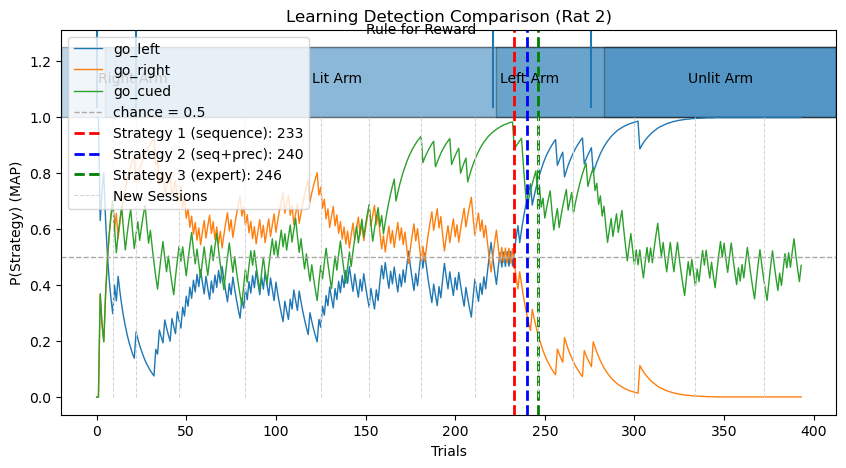

In [53]:
plt.figure(figsize=(10, 5))

# MAP curves (Figure 1d)
plt.plot(Output_collection["go_left"].MAPprobability, linewidth=1, label="go_left")
plt.plot(Output_collection["go_right"].MAPprobability, linewidth=1, label="go_right")
plt.plot(Output_collection["go_cued"].MAPprobability, linewidth=1, label="go_cued")

# Chance line
plt.axhline(0.5, color="darkgrey", linewidth=1, linestyle="--", label="chance = 0.5")

# Learning trials
plt.axvline(t1_paper, linewidth=2, linestyle="--", color="red", label=f"Strategy 1 (sequence): {t1_paper}")
plt.axvline(t2_paper, linewidth=2, linestyle="--", color="blue", label=f"Strategy 2 (seq+prec): {t2_paper}")
plt.axvline(t3, linewidth=2, linestyle="--", color="green", label=f"Strategy 3 (expert): {t3}")

# Session structure
plotSessionStructure(TestData)

plt.xlabel("Trials")
plt.ylabel("P(Strategy) (MAP)")
plt.title("Learning Detection Comparison (Rat 2)")
plt.legend()
plt.show()